# 03 — Feature Engineering + Baseline Model Comparison
**CMPE 188 | Flight Delay Prediction**

Goals:
- Engineer derived features from existing columns only (no external data)
- Establish a benchmark using raw + derived features
- Compare Random Forest vs XGBoost on equal footing
- Evaluate with accuracy, ROC-AUC, and classification report

*Weather enrichment (OpenMeteo API) is handled separately in `02_feature_engineering.ipynb`.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, chi2
from xgboost import XGBClassifier

DATA_PATH = "../data/raw/Airlines.csv"
df = pd.read_csv(DATA_PATH)

# Drop columns with no predictive signal
df = df.drop(columns=["id", "Flight"])

print(df.shape)
df.head()

(539383, 7)


,Airline,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,SFO,IAH,3,15,205,1
1,US,PHX,CLT,3,15,222,1
2,AA,LAX,DFW,3,20,165,1
3,AA,SFO,DFW,3,20,195,1
4,AS,ANC,SEA,3,30,202,0


## 1. Derived Feature Engineering

Features computed from existing columns only — no external data required.

| Feature | Source | Description |
|---|---|---|
| `time_bucket` | `Time` | morning / afternoon / evening / night |
| `is_peak_hour` | `Time` | 1 if 7–9 am or 5–8 pm |
| `route_volume` | `AirportFrom` + `AirportTo` | flight count per origin→dest pair (congestion proxy) |
| `airline_delay_rate` | `Airline` + `Delay` | historical delay rate per carrier — **computed on train split only** to avoid leakage |

In [2]:
def add_time_features(df):
    """Add time_bucket and is_peak_hour from the Time column (minutes from midnight)."""
    df = df.copy()
    hours = df["Time"] / 60
    df["time_bucket"] = pd.cut(
        hours,
        bins=[0, 6, 12, 18, 24],
        labels=["night", "morning", "afternoon", "evening"],
        right=False,
    ).astype(str)
    df["is_peak_hour"] = ((hours >= 7) & (hours < 9) | (hours >= 17) & (hours < 20)).astype(int)
    return df

def add_route_volume(df):
    """Count flights per origin→destination pair as a congestion proxy."""
    df = df.copy()
    route_counts = df.groupby(["AirportFrom", "AirportTo"]).transform("count")["Time"]
    df["route_volume"] = route_counts
    return df

df = add_time_features(df)
df = add_route_volume(df)
print("Added time_bucket, is_peak_hour, route_volume")
print(df[["Time", "time_bucket", "is_peak_hour", "route_volume"]].head(10))

Added time_bucket, is_peak_hour, route_volume
   Time time_bucket  is_peak_hour  route_volume
0    15       night             0           231
1    15       night             0           253
2    20       night             0           544
3    20       night             0           329
4    30       night             0           447
5    30       night             0           328
6    30       night             0           190
7    30       night             0           259
8    35       night             0           177
9    40       night             0           304


## 2. Train/Test Split + Airline Delay Rate

`airline_delay_rate` is computed on the **training split only** and then mapped to the test set — this prevents target leakage.

In [3]:
target = "Delay"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute airline delay rate on train only, then apply to both splits
airline_delay_rate = X_train.join(y_train).groupby("Airline")[target].mean()
global_rate = y_train.mean()  # fallback for unseen airlines

X_train = X_train.copy()
X_test = X_test.copy()
X_train["airline_delay_rate"] = X_train["Airline"].map(airline_delay_rate).fillna(global_rate)
X_test["airline_delay_rate"] = X_test["Airline"].map(airline_delay_rate).fillna(global_rate)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nairline_delay_rate sample:")
print(airline_delay_rate.sort_values(ascending=False))

Train: (431506, 10), Test: (107877, 10)

airline_delay_rate sample:
Airline
WN    0.697105
CO    0.567622
B6    0.465076
F9    0.455148
OO    0.453425
DL    0.449932
EV    0.400475
9E    0.397605
AA    0.388565
XE    0.380153
MQ    0.346699
AS    0.341466
US    0.334873
UA    0.326272
HA    0.318691
FL    0.301984
OH    0.276613
YV    0.242277
Name: Delay, dtype: float64


## 3. Preprocessing Pipeline

Shared across both models: OHE for categoricals, MinMaxScaler for numerics, SelectKBest chi2 for feature selection.

In [4]:
categorical_cols = ["Airline", "AirportFrom", "AirportTo", "time_bucket"]
numeric_cols = ["DayOfWeek", "Time", "Length", "is_peak_hour", "route_volume", "airline_delay_rate"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols),
    ]
)

# k=50 is a reasonable upper bound given the OHE expansion; tuned in notebook 04
selector = SelectKBest(score_func=chi2, k=50)

print("Categorical:", categorical_cols)
print("Numeric:    ", numeric_cols)

Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'time_bucket']
Numeric:     ['DayOfWeek', 'Time', 'Length', 'is_peak_hour', 'route_volume', 'airline_delay_rate']


## 4. XGBoost Baseline

In [5]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
    )),
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost  |  Accuracy: {xgb_acc:.4f}  |  ROC-AUC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=["No Delay", "Delayed"]))

XGBoost  |  Accuracy: 0.6438  |  ROC-AUC: 0.6895

              precision    recall  f1-score   support

    No Delay       0.64      0.82      0.72     59824
     Delayed       0.65      0.42      0.51     48053

    accuracy                           0.64    107877
   macro avg       0.65      0.62      0.62    107877
weighted avg       0.65      0.64      0.63    107877



## 5. Random Forest Baseline

In [6]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest  |  Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["No Delay", "Delayed"]))

Random Forest  |  Accuracy: 0.6384  |  ROC-AUC: 0.6848

              precision    recall  f1-score   support

    No Delay       0.62      0.90      0.73     59824
     Delayed       0.71      0.31      0.44     48053

    accuracy                           0.64    107877
   macro avg       0.67      0.61      0.59    107877
weighted avg       0.66      0.64      0.60    107877



## 6. Side-by-Side Results

                 Feature Set  Accuracy   ROC-AUC
Model                                           
XGBoost        raw + derived  0.643807  0.689482
Random Forest  raw + derived  0.638394  0.684844


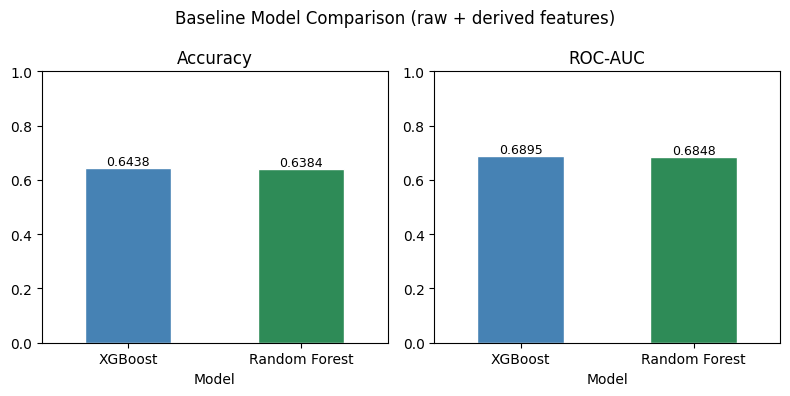

In [7]:
results = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest"],
    "Feature Set": ["raw + derived", "raw + derived"],
    "Accuracy": [xgb_acc, rf_acc],
    "ROC-AUC": [xgb_auc, rf_auc],
})
results = results.set_index("Model")
print(results.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, metric in zip(axes, ["Accuracy", "ROC-AUC"]):
    results[metric].plot(kind="bar", ax=ax, color=["steelblue", "seagreen"], edgecolor="white")
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Baseline Model Comparison (raw + derived features)")
plt.tight_layout()
plt.show()